# Module 7 — Styling and Themes

This module is the matplotlib counterpart to ggplot2's `theme()` system and `theme_*()` functions.

The goal is to stop styling each plot individually and instead set defaults once. By the end, the direction is toward a reusable Radiology AI Unit style that automatically applies to every figure.

The core mental model:

```text
┌─────────────────────────────────────────────────────────┐
│ rcParams = a giant dictionary of default settings.      │
│ Every matplotlib function reads from it.                │
│                                                         │
│ Change rcParams once → every subsequent plot reflects   │
│ the change. No more repeating yourself.                 │
└─────────────────────────────────────────────────────────┘
```

There are three layers of styling, in increasing order of permanence:

```text
┌────────────────────────────────────────────────────────────┐
│ Layer 1: Per-plot keyword arguments                        │
│ ax.plot(x, y, color="red", linewidth=2)                   │
│ → applies only to this call                                │
├────────────────────────────────────────────────────────────┤
│ Layer 2: rcParams modification, session-wide               │
│ plt.rcParams["axes.titlesize"] = 14                       │
│ → applies to all plots in this Python session              │
├────────────────────────────────────────────────────────────┤
│ Layer 3: Style sheets / matplotlibrc files                 │
│ plt.style.use("my-style")                                 │
│ → reusable, version-controllable, shareable                │
└────────────────────────────────────────────────────────────┘
```

The previous modules mostly used Layer 1. This module moves upward.

## 1. `rcParams`: the central settings dictionary

`rcParams`, short for runtime configuration parameters, is a dictionary-like object with hundreds of settings.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Inspect a setting
print(plt.rcParams["figure.figsize"])
print(plt.rcParams["axes.titlesize"])

[7.0, 5.0]
large


The keys are dot-namespaced by what they affect, such as:

- `figure.*`
- `axes.*`
- `xtick.*`
- `ytick.*`
- `legend.*`
- `font.*`
- `lines.*`

Changing a setting affects future plots in the current Python session.

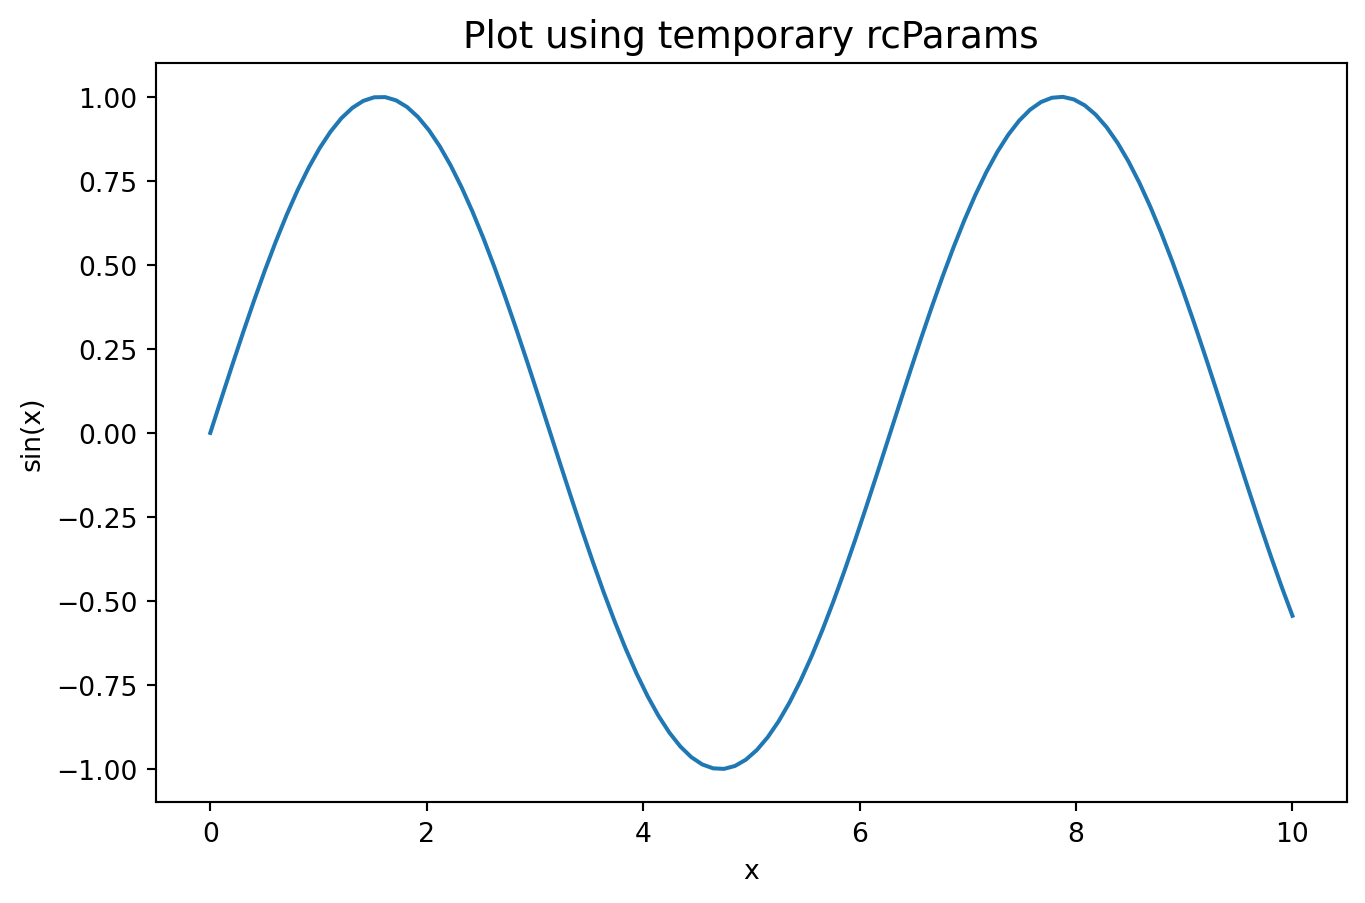

In [2]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

with mpl.rc_context({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.family": "sans-serif",
}):
    fig, ax = plt.subplots()
    ax.plot(x, y)
    ax.set_title("Plot using temporary rcParams")
    ax.set_xlabel("x")
    ax.set_ylabel("sin(x)")
    plt.show()

This example uses `mpl.rc_context(...)` so the settings are temporary and do not leak into the rest of the notebook. In normal project code, `plt.rcParams[...] = ...` or `plt.rcParams.update(...)` changes settings for all subsequent plots in the session.

A useful starter set:

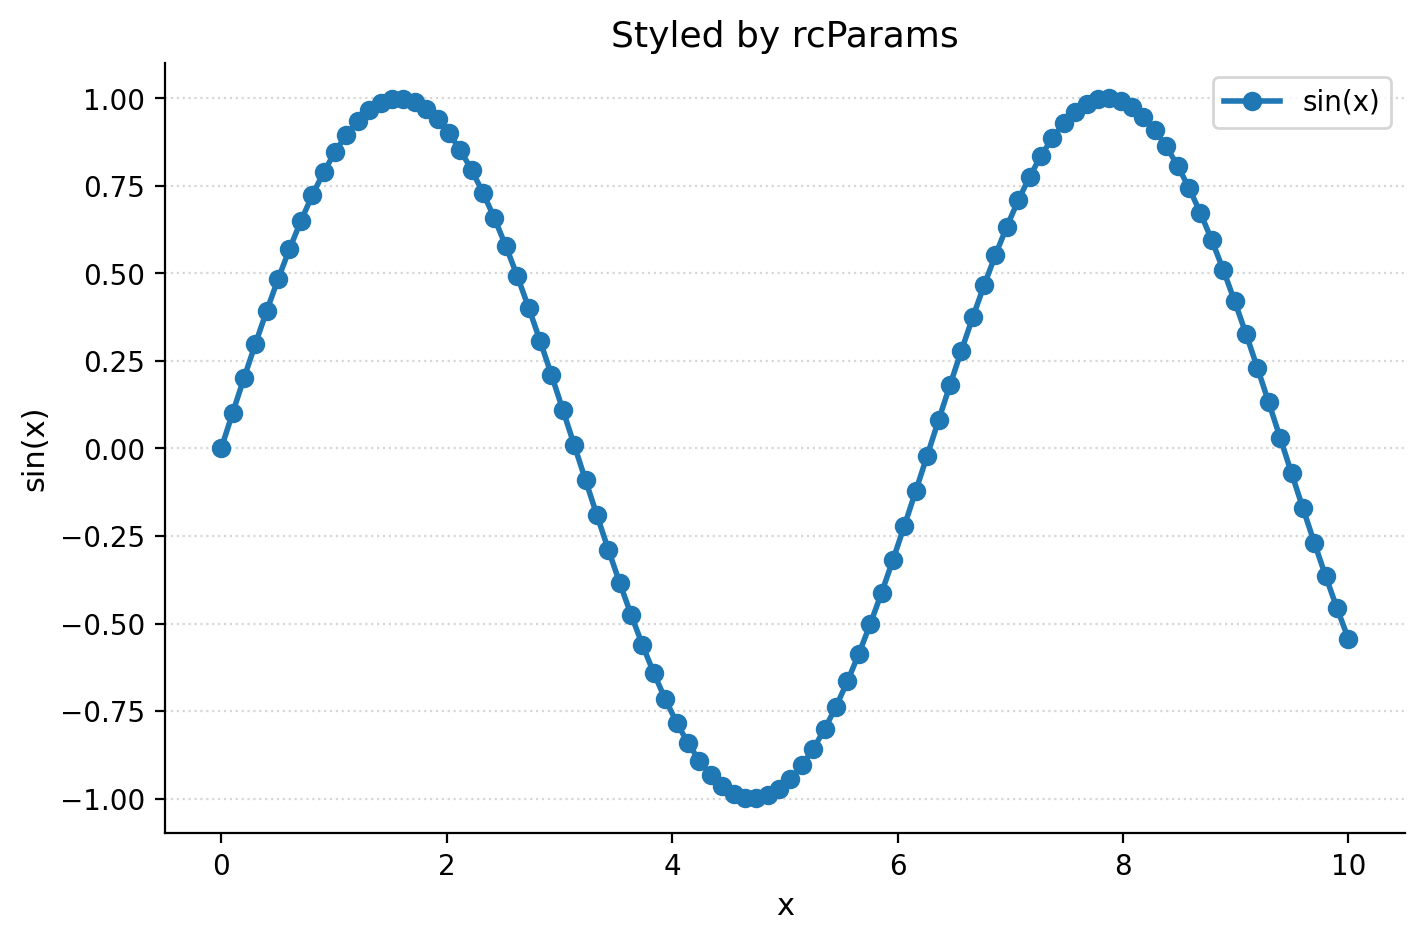

In [3]:
radiology_style = {
    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Fonts
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Axes appearance
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.linestyle": ":",
    "grid.alpha": 0.5,

    # Lines and markers
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
}

with mpl.rc_context(radiology_style):
    fig, ax = plt.subplots()
    ax.plot(x, y, marker="o", label="sin(x)")
    ax.set_title("Styled by rcParams")
    ax.set_xlabel("x")
    ax.set_ylabel("sin(x)")
    ax.legend()
    plt.show()

After these defaults are active, every new `fig, ax = plt.subplots()` inherits them. This removes repetitive boilerplate such as hiding the top and right spines or setting a light y-axis grid on every plot.

## 2. Discovering settings

There are two reliable discovery tools: search the keys and inspect the active `matplotlibrc` file.

In [4]:
# All rcParams keys that mention "tick"
tick_keys = [k for k in plt.rcParams if "tick" in k]
print(tick_keys[:20])
print(f"... {len(tick_keys)} tick-related keys total")

# Path to the active matplotlibrc reference file
print(mpl.matplotlib_fname())

['xtick.alignment', 'xtick.bottom', 'xtick.color', 'xtick.direction', 'xtick.labelbottom', 'xtick.labelcolor', 'xtick.labelsize', 'xtick.labeltop', 'xtick.major.bottom', 'xtick.major.pad', 'xtick.major.size', 'xtick.major.top', 'xtick.major.width', 'xtick.minor.bottom', 'xtick.minor.ndivs', 'xtick.minor.pad', 'xtick.minor.size', 'xtick.minor.top', 'xtick.minor.visible', 'xtick.minor.width']
... 42 tick-related keys total
/Users/kittipos/my_book/py-plot-notes/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/matplotlibrc


To reset everything to factory defaults:

```python
plt.rcdefaults()
```

The full list of defaults lives in a file called `matplotlibrc` inside the matplotlib installation. Treat it as a reference, not something to edit directly.